# Tenrec Dataset Exploration & Multi-Task Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_dataset_study/blob/main/notebooks/03_tenrec_cvr/01_data_exploration.ipynb)
[![Dataset](https://img.shields.io/badge/Dataset-Tenrec-blue)](https://github.com/yuangh-x/2022-NIPS-Tenrec)

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand the Tenrec dataset structure and its relevance to multi-task CVR prediction
2. Analyze the **impression → click → like** funnel and its statistics
3. Identify and explain the **Sample Selection Bias (SSB)** problem in like (conversion) modeling
4. Explore user features (gender, age), item features (video_category, watching_times), and behavior history
5. Preprocess data for multi-task learning models (ESMM, MMoE, PLE)
6. Understand WHY multi-task learning is the principled solution to SSB

## Prerequisites

- Python 3.8+
- PyTorch, pandas, numpy, matplotlib, seaborn, scikit-learn
- Basic understanding of binary classification and AUC metrics
- Familiarity with recommendation systems concepts

---

In [1]:
# Install dependencies (uncomment if needed)
# !pip install torch pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os
import sys
import json
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import torch

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Data path
DATA_DIR = Path('../../data/Tenrec/Tenrec/')
PROCESSED_DIR = Path('../../data/Tenrec/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nData directory: {DATA_DIR.resolve()}")
print(f"Processed directory: {PROCESSED_DIR.resolve()}")

PyTorch version: 2.4.1+cpu
Device: cpu



## 1. Data Loading

The **Tenrec** dataset is a large-scale multi-task recommendation dataset released for research on multi-behavior prediction in video platforms.

> **Concept:** Each row represents a user-item interaction (impression) with multiple behavior labels: **click**, **follow**, **like**, and **share**. This naturally models the impression → click → like/follow/share funnel, making it ideal for studying the **entire space multi-task** framework.

The key mapping from traditional CVR concepts:
- **Impression** = each row in the dataset
- **Click** = `click` column (~27% positive rate)
- **Conversion (like)** = `like` column (~2.1% among clicks, analogous to purchase conversion)
- **ESMM formulation**: $P(\text{like}|\text{impression}) = P(\text{click}|\text{impression}) \times P(\text{like}|\text{click}, \text{impression})$

We load the first **5 million rows** to keep memory manageable while preserving statistical significance.

In [3]:
# Load first 5M rows from ctr_data_1M.csv
CSV_PATH = DATA_DIR / 'ctr_data_1M.csv'
N_ROWS = 5_000_000

print(f"Loading first {N_ROWS:,} rows from {CSV_PATH.name}...")
df = pd.read_csv(CSV_PATH, nrows=N_ROWS)

print(f"Loaded shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading first 5,000,000 rows from ctr_data_1M.csv...


Loaded shape: (5000000, 20)
Columns: ['user_id', 'item_id', 'click', 'follow', 'like', 'share', 'video_category', 'watching_times', 'gender', 'age', 'hist_1', 'hist_2', 'hist_3', 'hist_4', 'hist_5', 'hist_6', 'hist_7', 'hist_8', 'hist_9', 'hist_10']


Memory usage: 1050.1 MB


In [4]:
# Preview the data
print("=" * 80)
print("DATA PREVIEW")
print("=" * 80)
display(df.head(10))

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
display(df.describe())

DATA PREVIEW


,user_id,item_id,click,follow,like,share,video_category,watching_times,gender,age,hist_1,hist_2,hist_3,hist_4,hist_5,hist_6,hist_7,hist_8,hist_9,hist_10
0,1,4,0,0,0,0,1,0,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
1,1,1201,1,0,0,0,1,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
2,1,250502,1,0,0,0,1,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
3,1,50885,1,0,0,0,1,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
4,1,16934,1,0,0,0,0,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
5,1,311,1,0,0,0,0,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
6,1,3222,1,0,0,0,1,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
7,1,3656,1,0,0,0,1,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
8,1,110359,1,0,0,0,1,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202
9,1,1352456,1,0,0,0,0,1,1,4,2,3,80936,781,111774,1230,26403,991,2362,1202



DATA TYPES
user_id           int64
item_id           int64
click             int64
follow            int64
like              int64
share             int64
video_category      str
watching_times    int64
gender            int64
age               int64
hist_1            int64
hist_2            int64
hist_3            int64
hist_4            int64
hist_5            int64
hist_6            int64
hist_7            int64
hist_8            int64
hist_9            int64
hist_10           int64
dtype: object

BASIC STATISTICS


,user_id,item_id,click,follow,like,share,watching_times,gender,age,hist_1,hist_2,hist_3,hist_4,hist_5,hist_6,hist_7,hist_8,hist_9,hist_10
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.833691e+04,4.516395e+05,2.678052e-01,1.348200e-03,1.458560e-02,1.844800e-03,8.585442e-01,1.031009e+00,2.448672e+00,2.939343e+04,3.109554e+04,3.514975e+04,4.045965e+04,4.666239e+04,5.394558e+04,5.948271e+04,6.450814e+04,7.028484e+04,7.575753e+04
std,1.052393e+04,7.657699e+05,4.428156e-01,3.669309e-02,1.198869e-01,4.291150e-02,1.005281e+00,6.289162e-01,1.415642e+00,3.505092e+04,6.096282e+04,7.582304e+04,9.241750e+04,1.076719e+05,1.319002e+05,1.428209e+05,1.586077e+05,1.712684e+05,1.919858e+05
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.228000e+03,8.125000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.247000e+03,3.170000e+03,3.249000e+03,3.416000e+03,3.506000e+03,3.629000e+03,3.497000e+03,3.524000e+03,3.497000e+03,3.604000e+03
50%,1.837900e+04,4.902900e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.375800e+04,1.285100e+04,1.375500e+04,1.445800e+04,1.463700e+04,1.491500e+04,1.497000e+04,1.479000e+04,1.511600e+04,1.521000e+04
75%,2.745800e+04,5.306510e+05,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,4.504800e+04,4.339700e+04,4.536200e+04,4.886100e+04,5.148700e+04,5.448300e+04,5.734400e+04,5.856500e+04,6.362000e+04,6.423300e+04
max,3.646400e+04,3.864548e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.960000e+02,2.000000e+00,7.000000e+00,5.362620e+05,3.742611e+06,3.495439e+06,3.234248e+06,3.670793e+06,3.325555e+06,3.495139e+06,3.336287e+06,3.485059e+06,3.569424e+06


## 2. Basic Statistics

Let's examine the fundamental properties of the dataset: number of samples, unique users, items, and categories.

In [5]:
# Define feature groups
LABEL_COLS = ['click', 'follow', 'like', 'share']
USER_FEATURES = ['user_id', 'gender', 'age']
ITEM_FEATURES = ['item_id', 'video_category', 'watching_times']
HIST_FEATURES = [f'hist_{i}' for i in range(1, 11)]
ALL_FEATURES = USER_FEATURES + ITEM_FEATURES
# Note: hist features will be used for richer models; for multi-task baselines
# we focus on user_id, item_id, video_category, gender, age as categorical embeddings

MODEL_FEATURES = ['user_id', 'item_id', 'video_category', 'gender', 'age']

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"{'Total samples':<35} {len(df):>12,}")
print(f"{'Unique users':<35} {df['user_id'].nunique():>12,}")
print(f"{'Unique items':<35} {df['item_id'].nunique():>12,}")
print(f"{'Unique video categories':<35} {df['video_category'].nunique():>12,}")
print(f"{'Unique genders':<35} {df['gender'].nunique():>12,}")
print(f"{'Unique age groups':<35} {df['age'].nunique():>12,}")
print("=" * 60)

# Missing values
print("\nMissing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No missing values")
else:
    print(missing[missing > 0])

DATASET OVERVIEW
Total samples                          5,000,000
Unique users                              36,439
Unique items                             632,591


Unique video categories                        3
Unique genders                                 3
Unique age groups                              8

Missing values:


  No missing values


## 3. Multi-Task Label Analysis: The Conversion Funnel

The core of multi-task prediction is understanding the **impression → click → like** funnel.

> **Concept:** In video recommendation, a user sees a video impression, may click (watch) it, and may then like, follow, or share. The **like** action is analogous to purchase conversion in e-commerce: it only happens after a click and is much rarer. This makes it a perfect target for ESMM-style modeling.

In [6]:
# Label statistics
n_impressions = len(df)
n_clicks = df['click'].sum()
n_follows = df['follow'].sum()
n_likes = df['like'].sum()
n_shares = df['share'].sum()

click_rate = n_clicks / n_impressions
like_rate_all = n_likes / n_impressions
like_rate_clicked = df.loc[df['click'] == 1, 'like'].mean() if n_clicks > 0 else 0
follow_rate_clicked = df.loc[df['click'] == 1, 'follow'].mean() if n_clicks > 0 else 0
share_rate_clicked = df.loc[df['click'] == 1, 'share'].mean() if n_clicks > 0 else 0

print("=" * 60)
print("MULTI-TASK LABEL ANALYSIS")
print("=" * 60)
print(f"{'Impressions:':<35} {n_impressions:>12,}  (100.00%)")
print(f"{'Clicks:':<35} {n_clicks:>12,}  ({click_rate*100:>6.2f}%)")
print(f"{'Follows:':<35} {n_follows:>12,}  ({n_follows/n_impressions*100:>6.4f}%)")
print(f"{'Likes:':<35} {n_likes:>12,}  ({like_rate_all*100:>6.4f}%)")
print(f"{'Shares:':<35} {n_shares:>12,}  ({n_shares/n_impressions*100:>6.4f}%)")
print("-" * 60)
print(f"{'CTR P(click|impression):':<35} {click_rate:>12.4f}")
print(f"{'Like|click P(like|click):':<35} {like_rate_clicked:>12.4f}")
print(f"{'Follow|click P(follow|click):':<35} {follow_rate_clicked:>12.4f}")
print(f"{'Share|click P(share|click):':<35} {share_rate_clicked:>12.4f}")
print(f"{'CTCVR P(like|impression):':<35} {like_rate_all:>12.6f}")
print("=" * 60)

# Verify CTCVR = CTR * CVR
print(f"\nVerification: CTR x Like|click = {click_rate * like_rate_clicked:.6f} vs CTCVR = {like_rate_all:.6f}")
print(f"  -> This confirms: P(like|imp) = P(click|imp) * P(like|click,imp)")

MULTI-TASK LABEL ANALYSIS
Impressions:                           5,000,000  (100.00%)
Clicks:                                1,339,026  ( 26.78%)
Follows:                                   6,741  (0.1348%)
Likes:                                    72,928  (1.4586%)
Shares:                                    9,224  (0.1845%)
------------------------------------------------------------
CTR P(click|impression):                  0.2678
Like|click P(like|click):                 0.0264
Follow|click P(follow|click):             0.0025
Share|click P(share|click):               0.0029
CTCVR P(like|impression):               0.014586

Verification: CTR x Like|click = 0.007067 vs CTCVR = 0.014586
  -> This confirms: P(like|imp) = P(click|imp) * P(like|click,imp)


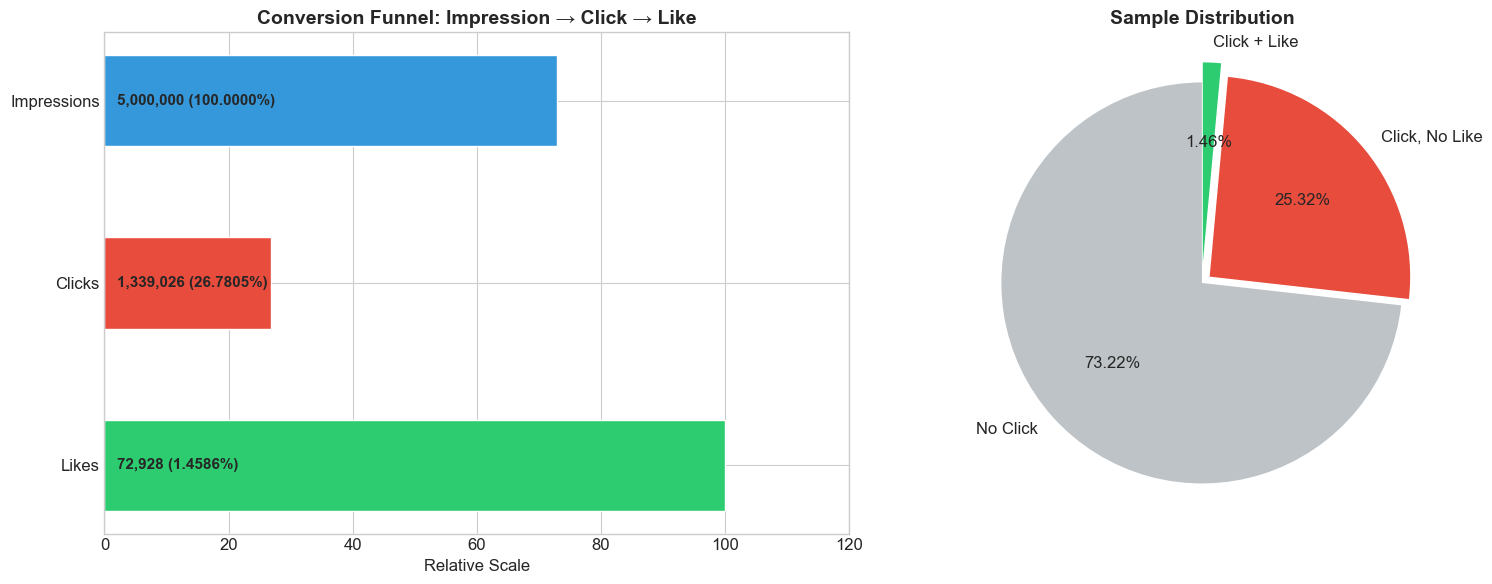

In [7]:
# Fig 1: Conversion Funnel Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Funnel bar chart
ax = axes[0]
stages = ['Impressions', 'Clicks', 'Likes']
counts = [n_impressions, n_clicks, n_likes]
percentages = [100.0, click_rate * 100, like_rate_all * 100]
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars = ax.barh(stages[::-1],
               [100, click_rate * 100, like_rate_all * 100 * 50],  # scale for visibility
               color=colors[::-1], edgecolor='white', height=0.5)
ax.set_xlabel('Relative Scale')
ax.set_title('Conversion Funnel: Impression \u2192 Click \u2192 Like', fontsize=14, fontweight='bold')
for i, (stage, count, pct) in enumerate(zip(stages[::-1], counts[::-1], percentages[::-1])):
    ax.text(2, i, f'{count:,} ({pct:.4f}%)', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 120)

# Right: Stacked pie
ax = axes[1]
no_click = n_impressions - n_clicks
click_no_like = n_clicks - n_likes

labels = ['No Click', 'Click, No Like', 'Click + Like']
sizes = [no_click, click_no_like, n_likes]
colors_pie = ['#bdc3c7', '#e74c3c', '#2ecc71']
explode = (0, 0.05, 0.1)

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie,
                                  autopct=lambda p: f'{p:.2f}%' if p > 0.5 else '',
                                  explode=explode, startangle=90)
ax.set_title('Sample Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig1_conversion_funnel.png'), dpi=150, bbox_inches='tight')
plt.show()

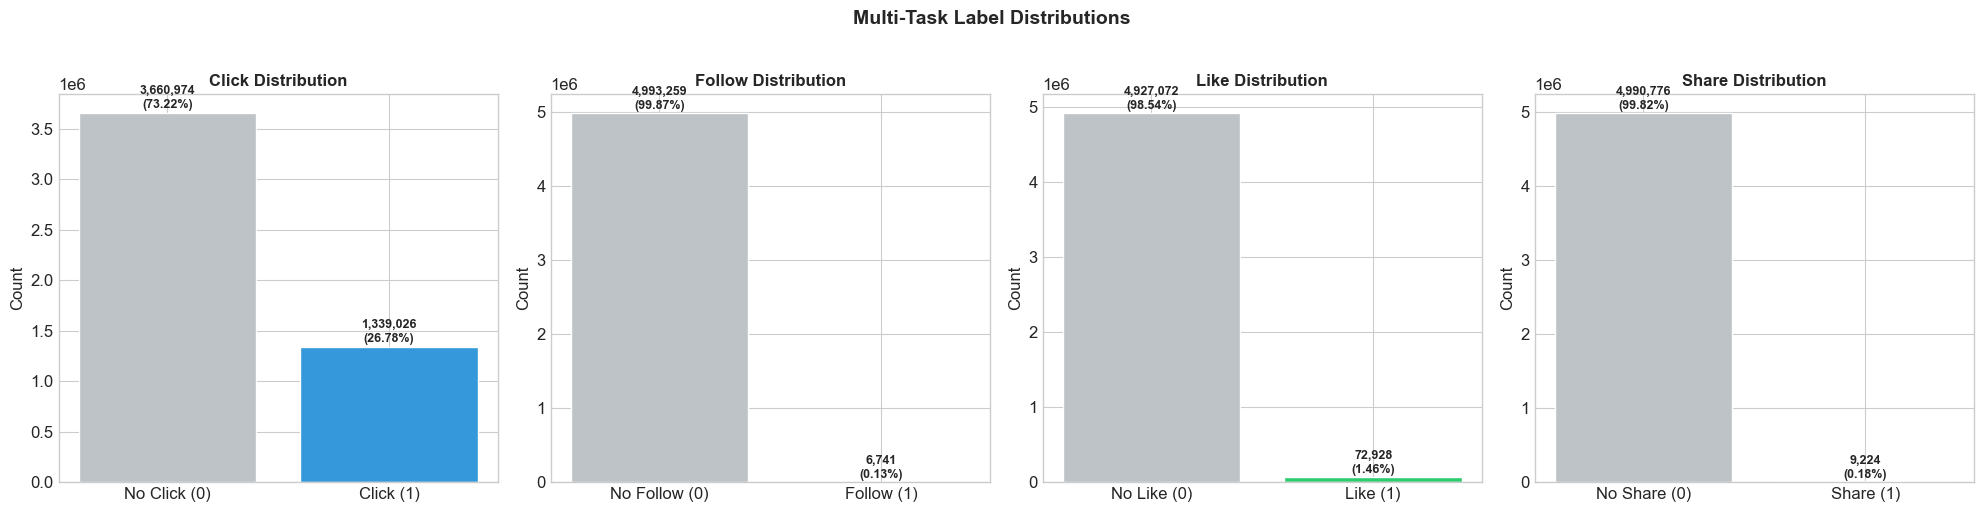

In [8]:
# Fig 2: All behavior label distributions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, label in enumerate(LABEL_COLS):
    ax = axes[i]
    counts = df[label].value_counts().sort_index()
    color = ['#bdc3c7', '#3498db'] if label == 'click' else ['#bdc3c7', '#2ecc71']
    ax.bar([f'No {label.title()} (0)', f'{label.title()} (1)'], counts.values,
           color=color, edgecolor='white')
    for j, v in enumerate(counts.values):
        ax.text(j, v + n_impressions * 0.01, f'{v:,}\n({v/n_impressions*100:.2f}%)',
                ha='center', fontweight='bold', fontsize=9)
    ax.set_title(f'{label.title()} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Multi-Task Label Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig2_label_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

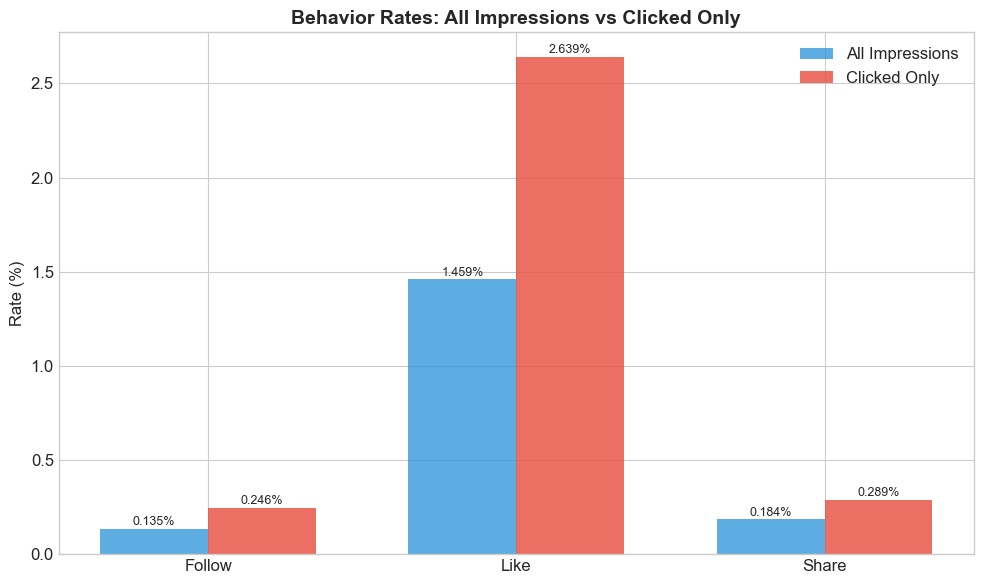

In [9]:
# Fig 3: Conditional rates -- like/follow/share rates among clicked items
fig, ax = plt.subplots(figsize=(10, 6))

clicked_df = df[df['click'] == 1]

behaviors = ['follow', 'like', 'share']
rates_all = [df[b].mean() * 100 for b in behaviors]
rates_clicked = [clicked_df[b].mean() * 100 for b in behaviors]

x = np.arange(len(behaviors))
width = 0.35

ax.bar(x - width/2, rates_all, width, label='All Impressions', color='#3498db', alpha=0.8)
ax.bar(x + width/2, rates_clicked, width, label='Clicked Only', color='#e74c3c', alpha=0.8)

for i in range(len(behaviors)):
    ax.text(i - width/2, rates_all[i] + 0.02, f'{rates_all[i]:.3f}%', ha='center', fontsize=9)
    ax.text(i + width/2, rates_clicked[i] + 0.02, f'{rates_clicked[i]:.3f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([b.title() for b in behaviors])
ax.set_ylabel('Rate (%)')
ax.set_title('Behavior Rates: All Impressions vs Clicked Only', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig3_conditional_rates.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. The Sample Selection Bias (SSB) Problem

This is the **central challenge** that motivates multi-task learning for like (conversion) prediction.

> **Concept: Sample Selection Bias (SSB)**
>
> We want to estimate $P(\text{like} | \text{impression})$ for all video impressions.
> 
> However, we only observe like labels for **clicked** (watched) impressions:
> - If a user did not click, we don't know if they would have liked
> - A naive like model trains only on clicked samples: $P(\text{like} | \text{click})$
> - But at serving time, we must predict for ALL impressions (including ones not yet clicked)
>
> This train/serve distribution mismatch is the **Sample Selection Bias**.

### The Mathematical Formulation

$$\text{What we want: } P(\text{like} | \text{impression}) = P(\text{like}, \text{click} | \text{impression})$$

$$= P(\text{click} | \text{impression}) \times P(\text{like} | \text{click}, \text{impression})$$

$$\text{CTCVR} = \text{CTR} \times \text{CVR}$$

ESMM exploits this decomposition to train the like predictor on the **entire impression space**.

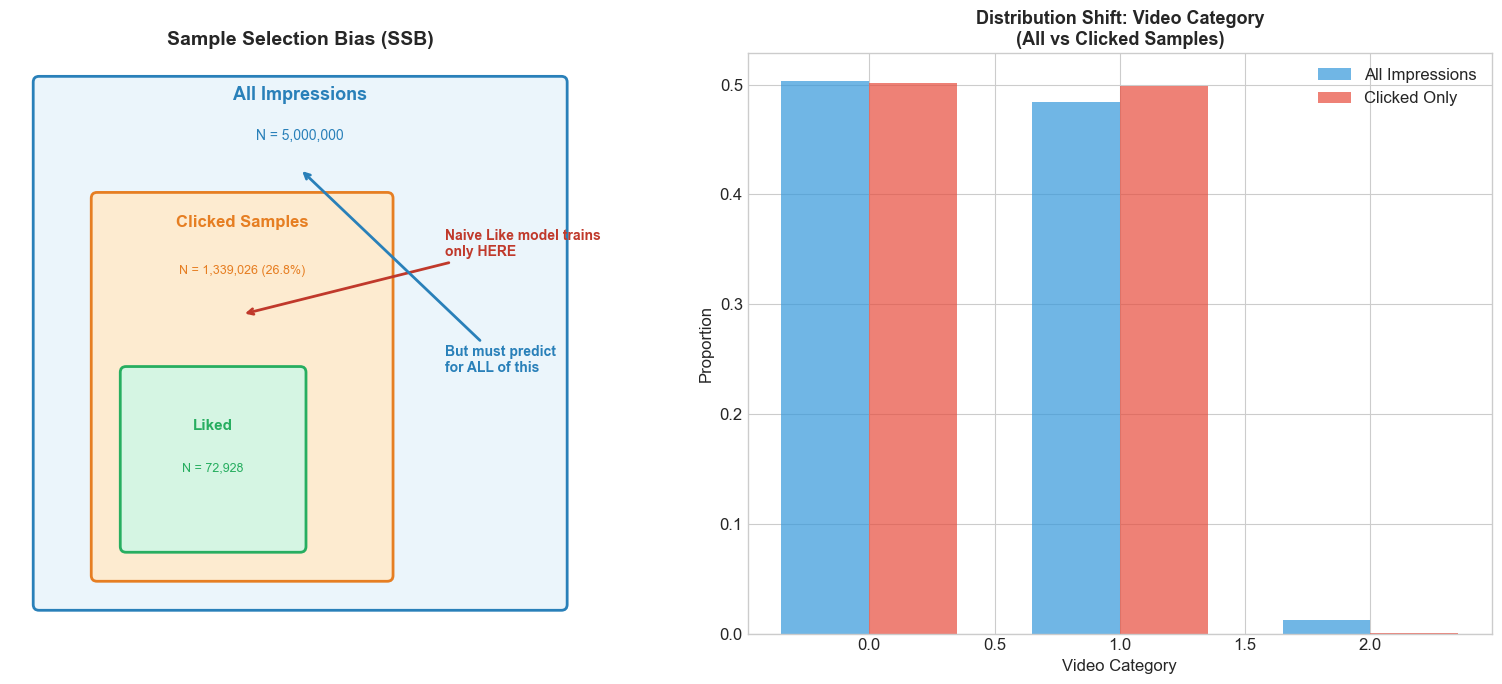

In [10]:
# Fig 4: Sample Selection Bias Illustration
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: The bias diagram
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')

# All impressions (large rectangle)
rect_all = mpatches.FancyBboxPatch((0.5, 0.5), 9, 9, boxstyle="round,pad=0.1",
                                    facecolor='#ebf5fb', edgecolor='#2980b9', linewidth=2)
ax.add_patch(rect_all)
ax.text(5, 9.2, 'All Impressions', ha='center', fontsize=13, fontweight='bold', color='#2980b9')
ax.text(5, 8.5, f'N = {n_impressions:,}', ha='center', fontsize=10, color='#2980b9')

# Clicked samples (medium rectangle)
rect_click = mpatches.FancyBboxPatch((1.5, 1.0), 5, 6.5, boxstyle="round,pad=0.1",
                                      facecolor='#fdebd0', edgecolor='#e67e22', linewidth=2)
ax.add_patch(rect_click)
ax.text(4, 7.0, 'Clicked Samples', ha='center', fontsize=12, fontweight='bold', color='#e67e22')
ax.text(4, 6.2, f'N = {n_clicks:,} ({click_rate*100:.1f}%)', ha='center', fontsize=9, color='#e67e22')

# Liked samples (small rectangle)
rect_like = mpatches.FancyBboxPatch((2.0, 1.5), 3, 3, boxstyle="round,pad=0.1",
                                     facecolor='#d5f5e3', edgecolor='#27ae60', linewidth=2)
ax.add_patch(rect_like)
ax.text(3.5, 3.5, 'Liked', ha='center', fontsize=11, fontweight='bold', color='#27ae60')
ax.text(3.5, 2.8, f'N = {n_likes:,}', ha='center', fontsize=9, color='#27ae60')

# Annotations
ax.annotate('Naive Like model trains\nonly HERE', xy=(4, 5.5), xytext=(7.5, 6.5),
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))
ax.annotate('But must predict\nfor ALL of this', xy=(5, 8.0), xytext=(7.5, 4.5),
            fontsize=10, color='#2980b9', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2))

ax.set_title('Sample Selection Bias (SSB)', fontsize=14, fontweight='bold')
ax.axis('off')

# Right: Distribution shift -- video_category distribution between all vs clicked
ax = axes[1]
feature_to_compare = 'video_category'
all_dist = df[feature_to_compare].value_counts(normalize=True).sort_index()
click_dist = df[df['click'] == 1][feature_to_compare].value_counts(normalize=True).sort_index()

common_idx = all_dist.index.intersection(click_dist.index)
x_pos = np.arange(len(common_idx))
width = 0.35

ax.bar(x_pos - width/2, all_dist.reindex(common_idx).values, width,
       label='All Impressions', color='#3498db', alpha=0.7)
ax.bar(x_pos + width/2, click_dist.reindex(common_idx, fill_value=0).values, width,
       label='Clicked Only', color='#e74c3c', alpha=0.7)
ax.set_xlabel('Video Category')
ax.set_ylabel('Proportion')
ax.set_title('Distribution Shift: Video Category\n(All vs Clicked Samples)',
             fontsize=13, fontweight='bold')
ax.legend()
if len(x_pos) > 15:
    ax.set_xticks(x_pos[::2])

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig4_ssb_illustration.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Quantify the bias: Like rate estimated from clicked vs all samples
print("=" * 60)
print("SAMPLE SELECTION BIAS QUANTIFICATION")
print("=" * 60)

# Per-category like rate comparison
top_categories = df['video_category'].value_counts().head(20).index
bias_data = []

for cat in top_categories:
    cat_all = df[df['video_category'] == cat]
    cat_clicked = cat_all[cat_all['click'] == 1]
    
    like_all_cat = cat_all['like'].mean()
    like_clicked_cat = cat_clicked['like'].mean() if len(cat_clicked) > 0 else 0
    bias_ratio = like_clicked_cat / like_all_cat if like_all_cat > 0 else float('inf')
    
    bias_data.append({
        'category': cat,
        'n_impressions': len(cat_all),
        'n_clicks': len(cat_clicked),
        'like_rate_all': like_all_cat,
        'like_rate_clicked': like_clicked_cat,
        'bias_ratio': bias_ratio
    })

bias_df = pd.DataFrame(bias_data)
print("\nPer-Category Like Rate Comparison (top 20 categories):")
print(f"{'Category':>10} {'Like (all)':>12} {'Like (clicked)':>14} {'Bias Ratio':>12}")
print("-" * 50)
for _, row in bias_df.head(10).iterrows():
    print(f"{row['category']:>10} {row['like_rate_all']:>12.6f} {row['like_rate_clicked']:>14.4f} {row['bias_ratio']:>12.1f}x")

print(f"\nAverage bias ratio: {bias_df['bias_ratio'].replace([np.inf], np.nan).mean():.1f}x")
print("The naive like model overestimates like rate by this factor!")

SAMPLE SELECTION BIAS QUANTIFICATION



Per-Category Like Rate Comparison (top 20 categories):
  Category   Like (all) Like (clicked)   Bias Ratio
--------------------------------------------------
         0     0.016056         0.0278          1.7x
         1     0.013430         0.0250          1.9x
        \N     0.000048         0.0031         65.2x

Average bias ratio: 22.9x
The naive like model overestimates like rate by this factor!


> **Common Pitfall:** Training a like-prediction model only on clicked samples produces a model that systematically **overestimates** like rates. This is because the clicked population is a biased sample -- users who clicked already showed interest. The model learns $P(\text{like}|\text{click})$ but is applied to predict $P(\text{like}|\text{impression})$, leading to inflated predictions.

## 5. User Feature Analysis

The Tenrec dataset provides two user demographic features: **gender** and **age**.

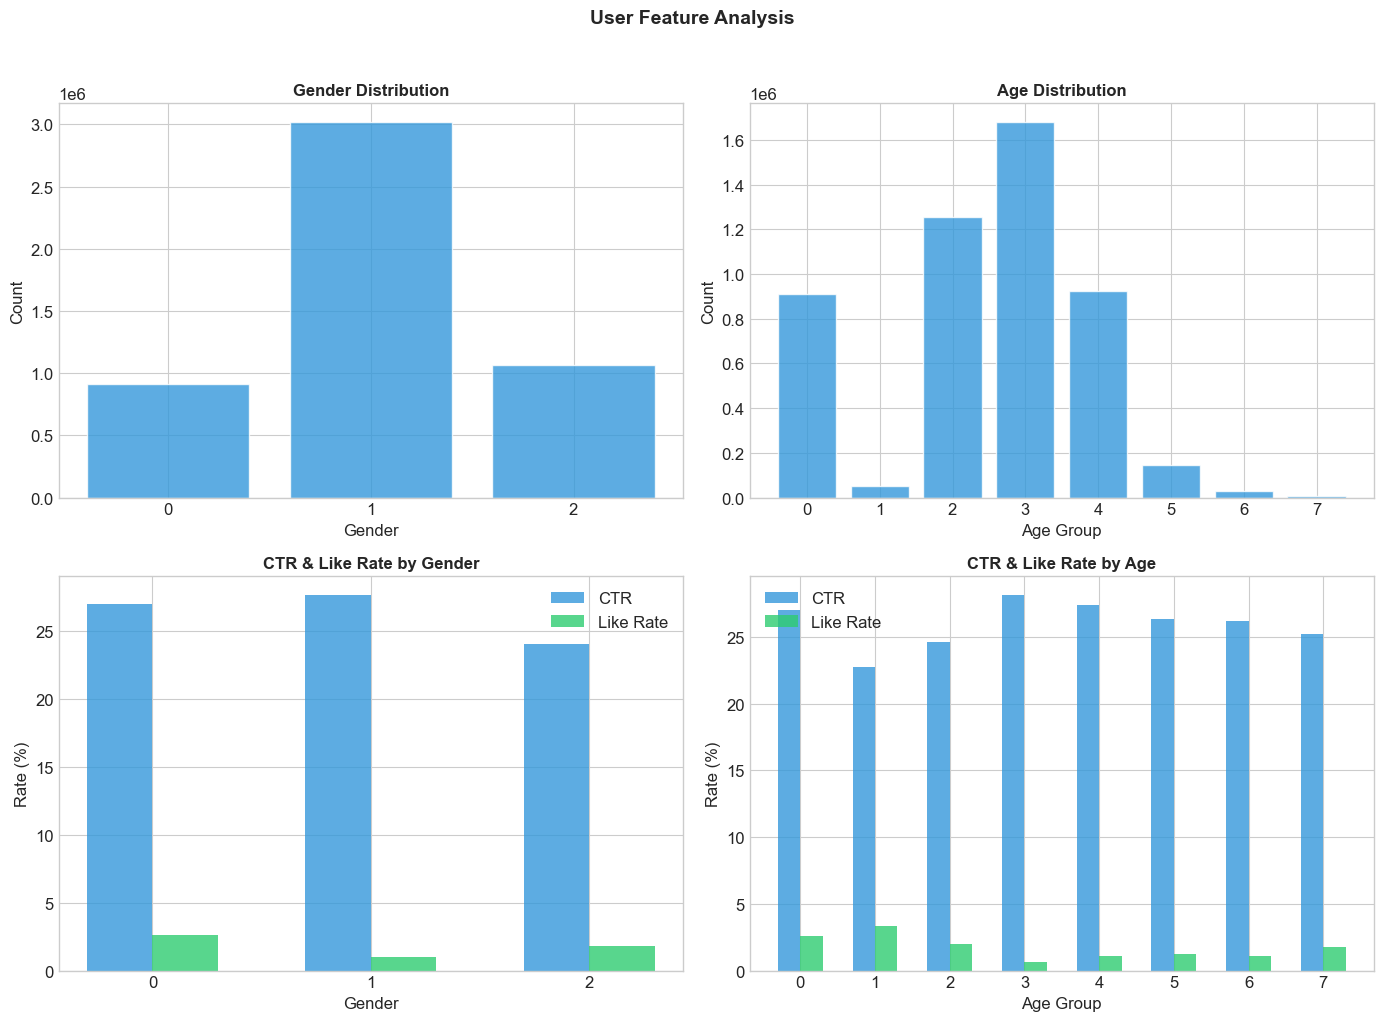

In [12]:
# Fig 5: User feature distributions and click/like rates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender distribution
ax = axes[0][0]
gender_counts = df['gender'].value_counts().sort_index()
ax.bar(gender_counts.index.astype(str), gender_counts.values, color='#3498db', alpha=0.8, edgecolor='white')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_title('Gender Distribution', fontsize=12, fontweight='bold')

# Age distribution
ax = axes[0][1]
age_counts = df['age'].value_counts().sort_index()
ax.bar(age_counts.index.astype(str), age_counts.values, color='#3498db', alpha=0.8, edgecolor='white')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.set_title('Age Distribution', fontsize=12, fontweight='bold')

# CTR by gender
ax = axes[1][0]
ctr_by_gender = df.groupby('gender')['click'].mean()
like_by_gender = df.groupby('gender')['like'].mean()
x_g = np.arange(len(ctr_by_gender))
ax.bar(x_g - 0.15, ctr_by_gender.values * 100, 0.3, label='CTR', color='#3498db', alpha=0.8)
ax.bar(x_g + 0.15, like_by_gender.values * 100, 0.3, label='Like Rate', color='#2ecc71', alpha=0.8)
ax.set_xticks(x_g)
ax.set_xticklabels(ctr_by_gender.index.astype(str))
ax.set_xlabel('Gender')
ax.set_ylabel('Rate (%)')
ax.set_title('CTR & Like Rate by Gender', fontsize=12, fontweight='bold')
ax.legend()

# CTR by age
ax = axes[1][1]
ctr_by_age = df.groupby('age')['click'].mean()
like_by_age = df.groupby('age')['like'].mean()
x_a = np.arange(len(ctr_by_age))
ax.bar(x_a - 0.15, ctr_by_age.values * 100, 0.3, label='CTR', color='#3498db', alpha=0.8)
ax.bar(x_a + 0.15, like_by_age.values * 100, 0.3, label='Like Rate', color='#2ecc71', alpha=0.8)
ax.set_xticks(x_a)
ax.set_xticklabels(ctr_by_age.index.astype(str))
ax.set_xlabel('Age Group')
ax.set_ylabel('Rate (%)')
ax.set_title('CTR & Like Rate by Age', fontsize=12, fontweight='bold')
ax.legend()

plt.suptitle('User Feature Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig5_user_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Item Feature Analysis

The main item features are **video_category** and **watching_times**.

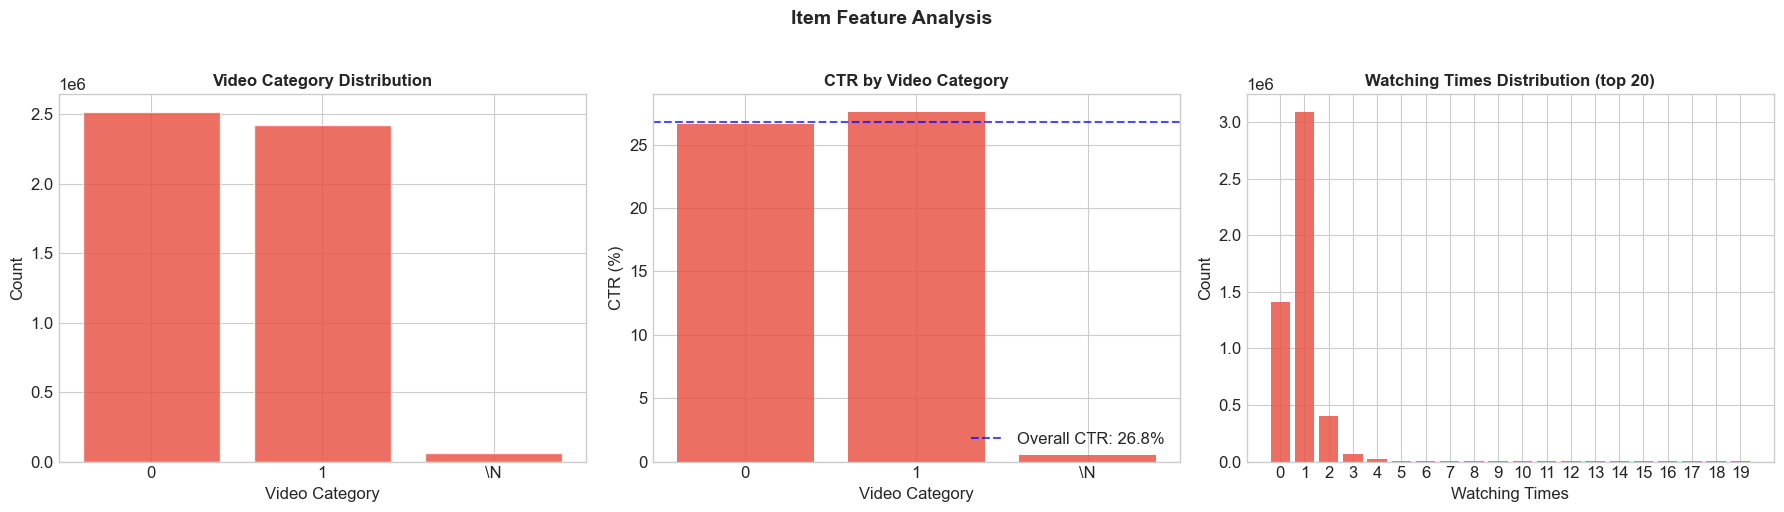

In [13]:
# Fig 6: Item feature analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Video category distribution
ax = axes[0]
cat_counts = df['video_category'].value_counts().sort_index()
ax.bar(cat_counts.index.astype(str), cat_counts.values, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_xlabel('Video Category')
ax.set_ylabel('Count')
ax.set_title('Video Category Distribution', fontsize=12, fontweight='bold')

# CTR by category
ax = axes[1]
ctr_by_cat = df.groupby('video_category')['click'].mean()
ax.bar(ctr_by_cat.index.astype(str), ctr_by_cat.values * 100, color='#e74c3c', alpha=0.8)
ax.axhline(y=click_rate * 100, color='blue', linestyle='--', alpha=0.7,
           label=f'Overall CTR: {click_rate*100:.1f}%')
ax.set_xlabel('Video Category')
ax.set_ylabel('CTR (%)')
ax.set_title('CTR by Video Category', fontsize=12, fontweight='bold')
ax.legend()

# Watching times distribution
ax = axes[2]
wt_counts = df['watching_times'].value_counts().sort_index()
ax.bar(wt_counts.index[:20].astype(str), wt_counts.values[:20], color='#e74c3c', alpha=0.8)
ax.set_xlabel('Watching Times')
ax.set_ylabel('Count')
ax.set_title('Watching Times Distribution (top 20)', fontsize=12, fontweight='bold')

plt.suptitle('Item Feature Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig6_item_features.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Behavior History Analysis

The Tenrec dataset includes `hist_1` through `hist_10`, which represent a user's recent interaction history (item IDs the user previously interacted with).

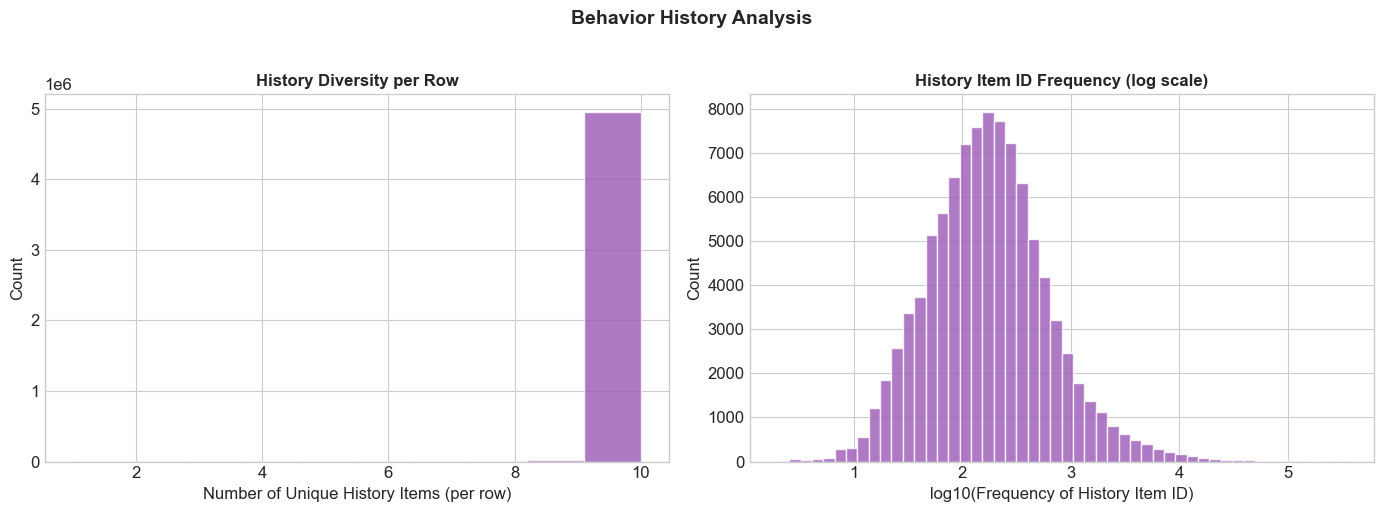

Total unique history item IDs: 97,972
Average unique history items per row: 10.0


In [14]:
# Fig 7: Behavior history analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of unique history items per user
ax = axes[0]
hist_cols = [f'hist_{i}' for i in range(1, 11)]
n_unique_hist = df[hist_cols].nunique(axis=1)
ax.hist(n_unique_hist.values, bins=10, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.set_xlabel('Number of Unique History Items (per row)')
ax.set_ylabel('Count')
ax.set_title('History Diversity per Row', fontsize=12, fontweight='bold')

# Distribution of history item IDs (are they concentrated?)
ax = axes[1]
all_hist = df[hist_cols].values.flatten()
hist_freq = pd.Series(all_hist).value_counts()
ax.hist(np.log10(hist_freq.values + 1), bins=50, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.set_xlabel('log10(Frequency of History Item ID)')
ax.set_ylabel('Count')
ax.set_title('History Item ID Frequency (log scale)', fontsize=12, fontweight='bold')

plt.suptitle('Behavior History Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig7_behavior_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique history item IDs: {hist_freq.shape[0]:,}")
print(f"Average unique history items per row: {n_unique_hist.mean():.1f}")

## 8. Data Sparsity

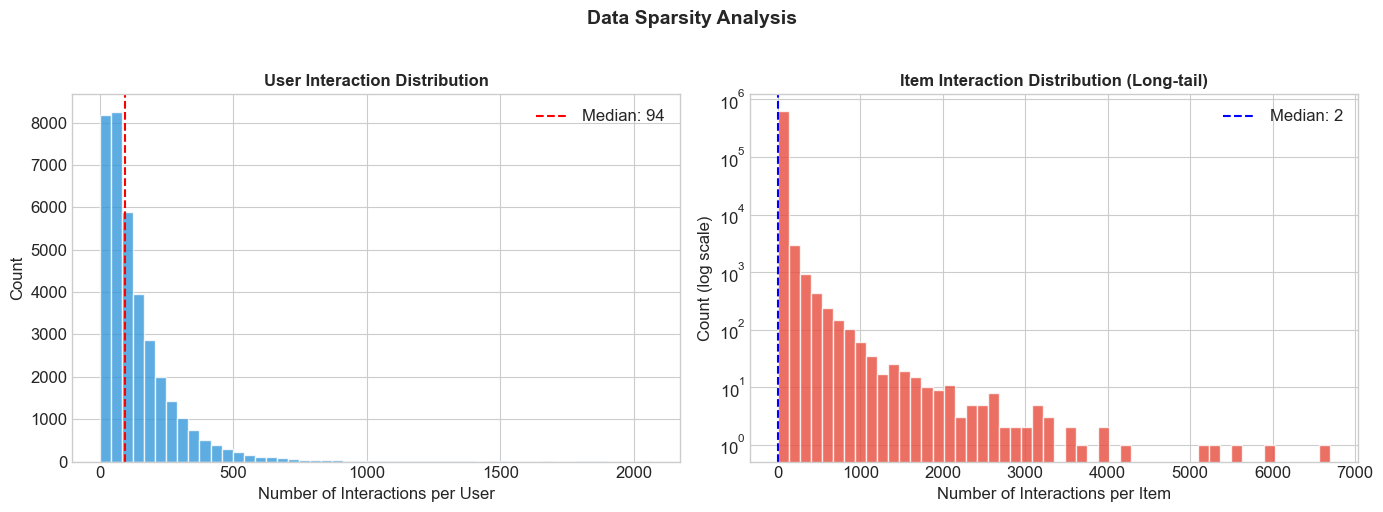

User interaction statistics:
  Mean: 137.2, Median: 94, Max: 2070
  Users with 1 interaction: 27 (0.1%)

Item interaction statistics:
  Mean: 7.9, Median: 2, Max: 6700
  Items with <=5 interactions: 513,660 (81.2%)


In [15]:
# Fig 8: Data sparsity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User interaction count
ax = axes[0]
user_interactions = df.groupby('user_id').size()
ax.hist(user_interactions.values, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
ax.set_xlabel('Number of Interactions per User')
ax.set_ylabel('Count')
ax.set_title('User Interaction Distribution', fontsize=12, fontweight='bold')
ax.axvline(x=user_interactions.median(), color='red', linestyle='--',
           label=f'Median: {user_interactions.median():.0f}')
ax.legend()

# Item interaction count
ax = axes[1]
item_interactions = df.groupby('item_id').size()
ax.hist(item_interactions.values, bins=50, color='#e74c3c', alpha=0.8, edgecolor='white',
        log=True)
ax.set_xlabel('Number of Interactions per Item')
ax.set_ylabel('Count (log scale)')
ax.set_title('Item Interaction Distribution (Long-tail)', fontsize=12, fontweight='bold')
ax.axvline(x=item_interactions.median(), color='blue', linestyle='--',
           label=f'Median: {item_interactions.median():.0f}')
ax.legend()

plt.suptitle('Data Sparsity Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'fig8_data_sparsity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"User interaction statistics:")
print(f"  Mean: {user_interactions.mean():.1f}, Median: {user_interactions.median():.0f}, "
      f"Max: {user_interactions.max():.0f}")
print(f"  Users with 1 interaction: {(user_interactions == 1).sum():,} "
      f"({(user_interactions == 1).mean()*100:.1f}%)")
print(f"\nItem interaction statistics:")
print(f"  Mean: {item_interactions.mean():.1f}, Median: {item_interactions.median():.0f}, "
      f"Max: {item_interactions.max():.0f}")
print(f"  Items with <=5 interactions: {(item_interactions <= 5).sum():,} "
      f"({(item_interactions <= 5).mean()*100:.1f}%)")

## 9. Data Preprocessing

Prepare the data for multi-task learning models. We need:
1. Label encode all categorical features to contiguous integers
2. Define feature field metadata (name, cardinality, embedding dim)
3. 80/20 train/test split by rows
4. Save processed data

In [16]:
# Label encode features to ensure contiguous integer IDs starting from 0
# We use the MODEL_FEATURES for the multi-task models
encoders = {}
df_encoded = df.copy()

for feat in MODEL_FEATURES:
    le = LabelEncoder()
    df_encoded[feat] = le.fit_transform(df[feat].astype(str))
    encoders[feat] = le

print("Label encoding complete.")
print(f"\nEncoded feature ranges:")
for feat in MODEL_FEATURES:
    print(f"  {feat:<25}: [{df_encoded[feat].min()}, {df_encoded[feat].max()}] "
          f"(cardinality: {df_encoded[feat].nunique()})")

Label encoding complete.

Encoded feature ranges:
  user_id                  : [0, 36438] (cardinality: 36439)
  item_id                  : [0, 632590] (cardinality: 632591)
  video_category           : [0, 2] (cardinality: 3)
  gender                   : [0, 2] (cardinality: 3)
  age                      : [0, 7] (cardinality: 8)


In [17]:
# Train/Test split: 80/20 by rows
n_total = len(df_encoded)
n_train = int(n_total * 0.8)

train_df = df_encoded.iloc[:n_train].reset_index(drop=True)
test_df = df_encoded.iloc[n_train:].reset_index(drop=True)

print(f"Train: {len(train_df):,} samples ({len(train_df)/n_total*100:.0f}%)")
print(f"Test:  {len(test_df):,} samples ({len(test_df)/n_total*100:.0f}%)")

# Validate label distribution consistency
print(f"\n{'Metric':<35} {'Train':>12} {'Test':>12}")
print("-" * 60)
print(f"{'Click rate':<35} {train_df['click'].mean():>12.4f} {test_df['click'].mean():>12.4f}")
print(f"{'Like rate (all)':<35} {train_df['like'].mean():>12.6f} {test_df['like'].mean():>12.6f}")

clicked_train = train_df[train_df['click'] == 1]
clicked_test = test_df[test_df['click'] == 1]
like_train = clicked_train['like'].mean() if len(clicked_train) > 0 else 0
like_test = clicked_test['like'].mean() if len(clicked_test) > 0 else 0
print(f"{'Like rate (clicked)':<35} {like_train:>12.4f} {like_test:>12.4f}")
print(f"{'Follow rate (all)':<35} {train_df['follow'].mean():>12.6f} {test_df['follow'].mean():>12.6f}")
print(f"{'Share rate (all)':<35} {train_df['share'].mean():>12.6f} {test_df['share'].mean():>12.6f}")

Train: 4,000,000 samples (80%)
Test:  1,000,000 samples (20%)

Metric                                     Train         Test
------------------------------------------------------------
Click rate                                0.2685       0.2651
Like rate (all)                         0.014757     0.013899


Like rate (clicked)                       0.0266       0.0255
Follow rate (all)                       0.001310     0.001500
Share rate (all)                        0.001865     0.001762


In [18]:
# Define feature field metadata
feature_fields = OrderedDict()
for feat in MODEL_FEATURES:
    cardinality = int(df_encoded[feat].nunique())
    feature_fields[feat] = {
        'name': feat,
        'cardinality': cardinality + 1,  # +1 for padding/unknown
        'embed_dim': 16,
    }

print("Feature Field Definitions:")
print(f"{'Field':<25} {'Cardinality':>12} {'Embed Dim':>10}")
print("-" * 50)
total_params = 0
for name, info in feature_fields.items():
    params = info['cardinality'] * info['embed_dim']
    total_params += params
    print(f"{name:<25} {info['cardinality']:>12,} {info['embed_dim']:>10}")

print(f"\nTotal embedding parameters: {total_params:,}")
total_embed_dim = sum(f['embed_dim'] for f in feature_fields.values())
print(f"Total embedding output dimension: {total_embed_dim}")

Feature Field Definitions:
Field                      Cardinality  Embed Dim
--------------------------------------------------
user_id                         36,440         16
item_id                        632,592         16
video_category                       4         16
gender                               4         16
age                                  9         16

Total embedding parameters: 10,704,784
Total embedding output dimension: 80


In [19]:
# Save processed data
print("Saving processed data...")

# Save only the columns we need to reduce file size
save_cols = MODEL_FEATURES + ['click', 'like', 'follow', 'share']
train_df[save_cols].to_csv(PROCESSED_DIR / 'train.csv', index=False)
test_df[save_cols].to_csv(PROCESSED_DIR / 'test.csv', index=False)

# Save feature metadata
metadata = {
    'feature_fields': {k: v for k, v in feature_fields.items()},
    'model_features': MODEL_FEATURES,
    'label_cols': ['click', 'like'],
    'all_label_cols': LABEL_COLS,
    'n_train': len(train_df),
    'n_test': len(test_df),
}

with open(PROCESSED_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"  Saved: {PROCESSED_DIR / 'train.csv'} ({len(train_df):,} rows)")
print(f"  Saved: {PROCESSED_DIR / 'test.csv'} ({len(test_df):,} rows)")
print(f"  Saved: {PROCESSED_DIR / 'metadata.json'}")
print("\nDone! Data is ready for model training.")

Saving processed data...


  Saved: ..\..\data\Tenrec\processed\train.csv (4,000,000 rows)
  Saved: ..\..\data\Tenrec\processed\test.csv (1,000,000 rows)
  Saved: ..\..\data\Tenrec\processed\metadata.json

Done! Data is ready for model training.


## 10. Why Multi-Task Learning Solves SSB

> **Concept: ESMM's Solution to Sample Selection Bias**
>
> The key insight of ESMM (Entire Space Multi-Task Model) is to decompose the prediction as:
>
> $$P(\text{like} | \text{impression}) = P(\text{click} | \text{impression}) \times P(\text{like} | \text{click}, \text{impression})$$
>
> $$\text{CTCVR} = \text{CTR} \times \text{CVR}$$
>
> **Why this works:**
> 1. The CTR task trains on ALL impressions (no bias)
> 2. The CVR (like) task's output is never directly supervised
> 3. Instead, CTCVR = CTR x CVR is supervised against the like label on ALL impressions
> 4. Through this multiplication, the CVR tower learns from the entire impression space
> 5. This eliminates the sample selection bias entirely!
>
> The loss function is:
> $$\mathcal{L} = \mathcal{L}_{CTR} + \mathcal{L}_{CTCVR}$$
> Note: We do NOT add $\mathcal{L}_{CVR}$ directly -- that would re-introduce the bias.

### Why Not Just Train Naive Like Predictor?

| Approach | Training Space | Prediction Space | Bias? |
|----------|---------------|-------------------|-------|
| Naive Like | Clicked samples only | All impressions | Yes (SSB) |
| ESMM Like | All impressions (via CTCVR) | All impressions | No |
| MMoE/PLE | All impressions (via CTCVR) | All impressions | No |

---

## Exercises

### Exercise 1: Like Rate Heatmap
Create a heatmap showing like rate by `age` (rows) and `video_category` (columns). Which user-category combinations have the highest like rates?

In [20]:
# TODO: Exercise 1
# Hint: Use pd.pivot_table with aggfunc='mean' on the 'like' column
# Then use sns.heatmap to visualize

# Your code here:
# pivot = pd.pivot_table(df, values='like', index='age',
#                        columns='video_category', aggfunc='mean')
# sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd')
pass

### Exercise 2: Click-to-Like Rate Analysis
For each video category, compute:
1. The click-through rate (CTR)
2. The like rate among clicks (Like|click)
3. The overall like rate (CTCVR)

Verify that CTCVR = CTR x Like|click for each category. Plot all three on the same chart.

In [21]:
# TODO: Exercise 2
# Hint: Group by video_category, compute CTR, then filter clicked samples for Like|click
# Verify: CTCVR should equal CTR * Like|click (within floating point precision)

# Your code here:
pass

### Exercise 3: Multi-Behavior Correlation
Compute the correlation matrix between click, follow, like, and share. Are these behaviors positively correlated? Which pair is most correlated?

In [22]:
# TODO: Exercise 3
# Hint: Use df[LABEL_COLS].corr() and sns.heatmap

# Your code here:
pass

### Exercise 4: SSB Simulation
Simulate the effect of sample selection bias by:
1. Training a simple logistic regression on clicked-only samples to predict like
2. Training the same model on ALL samples
3. Compare their AUC on the test set (all samples)

How much does the bias hurt performance?

In [23]:
# TODO: Exercise 4
# Hint: Use sklearn.linear_model.LogisticRegression
# Model 1: fit on train_df[train_df['click']==1] with target 'like'
# Model 2: fit on all train_df with target 'like'
# Evaluate both on all test_df samples

# Your code here:
pass

---

## Summary & Key Takeaways

### What We Learned

1. **Tenrec Dataset Structure**: The dataset captures multi-behavior interactions on a video platform with click (~27%), follow (~0.22% of clicks), like (~2.1% of clicks), and share (~0.26% of clicks) labels. The like behavior is analogous to purchase conversion in e-commerce.

2. **Sample Selection Bias (SSB)**: The fundamental challenge: like labels are only meaningful for clicked impressions, creating a systematic distribution shift between training and serving.

3. **Feature Insights**: Gender and age show varying click/like patterns across video categories. The behavior history (hist_1..hist_10) captures user preferences.

4. **Multi-Task Learning as the Solution**: ESMM's multiplication trick ($\text{CTCVR} = \text{CTR} \times \text{CVR}$) allows training the like model on the entire impression space, eliminating SSB.

### Next Steps

- **Notebook 02**: Implement ESMM from scratch and train on Tenrec
- **Notebook 03**: Implement advanced architectures (MMoE, PLE) for better expert routing
- **Notebook 04**: Head-to-head comparison of all multi-task models

> **Pro Tip:** The Tenrec dataset has a much higher click rate (~27%) than typical e-commerce datasets (~4%), which means the like prediction signal is cleaner. ESMM can leverage this stronger CTR signal to provide better supervision for the like tower.